# C2 Cholesky Factorisation Optimisation

The purpose of this notebook is to visualise the results from the different optimisation strategies applied to the Cholesky Factorisation algorithm.

-----

Import libraries


In [25]:
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd

Latex styling for plots

In [26]:
#latex styling for plots
plt.rcParams.update({
    "font.family": "serif",  
    "font.size": 10,         
    "axes.labelsize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "xtick.top": True,
    "ytick.right": True,
    "legend.fontsize": 8,
    "figure.titlesize": 12
})

Define figure and csv paths


In [27]:
FIGS_DIR = Path('../../figs')
FIGS_DIR.mkdir(parents=True, exist_ok=True)

CSV_PATH = Path('../../output')
RUN_PREFIX = 'run_'
TARGET_SIZE = 4096
LATEX_FIGSIZE = (8, 5)

In [28]:
SERIAL_VERSIONS = [
    ('v1_baseline', 'Baseline (v1)'),
    ('v2_loop_order', 'Loop order (v2)'),
    ('v3_scalar_hoisting', 'Scalar hoisting (v3)'),
    ('v4_pointers', 'Pointers (v4)'),
    ('v5_merge_loop', 'Merge loop (v5)'),
    ('v6_cache_blocking', 'Cache blocking (v6)'),
    ('v7_serial', 'Combined serial (v7)'),
]

In [29]:
PARALLEL_MATRIX_VERSIONS = [
    ('v1_baseline', 'Baseline (v1)'),
    ('v7_serial', 'Serial (v7)'),
    ('v8_parallel_naive', 'Parallel Naive (v8)'),
    ('v9_parallel_static', 'Parallel Static (v9)'),
    ('v10_parallel_dynamic', 'Parallel Dynamic (v10)'),
    ('v11_parallel', 'Parallel Combined (v11)'),
]

In [30]:
THREAD_VERSIONS = [
    ('v8_parallel_naive', 'Parallel Naive (v8)'),
    ('v9_parallel_static', 'Parallel Static (v9)'),
    ('v10_parallel_dynamic', 'Parallel Dynamic (v10)'),
    ('v11_parallel', 'Parallel Combined (v11)'),
]

In [31]:
SERIAL_BASELINE_LABEL = SERIAL_VERSIONS[0][1]
PARALLEL_BASELINE_LABEL = PARALLEL_MATRIX_VERSIONS[0][1]

Define functions for plots and results

In [32]:
from typing import Any


def run_columns(df: pd.DataFrame) -> list[str]:
    """Return columns that store repeated run timings."""
    return [col for col in df.columns if col.startswith(RUN_PREFIX)]


def add_average_time(df: pd.DataFrame, column_name: str = 'average_time') -> pd.DataFrame:
    """Add an average runtime column calculated from run columns."""
    df = df.copy()
    df[column_name] = df[run_columns(df)].mean(axis=1)
    return df


def load_matrix_versions(version_pairs: list[tuple[str, str]]) -> list[dict[str, Any]]:
    """Load matrix-size benchmark CSV files for each version."""
    frames: list[dict[str, Any]] = []
    for version_key, label in version_pairs:
        path = CSV_PATH / f'{version_key}_matrix_size_runs.csv'
        df = add_average_time(pd.read_csv(path))
        frames.append({'label': label, 'path': path, 'df': df})
    return frames


def get_matrix_sizes(entries: list[dict[str, Any]]) -> list[int]:
    """Collect and sort all unique matrix sizes in the loaded data."""
    sizes = {size for entry in entries for size in entry['df']['matrix_size'].unique()}
    return sorted(sizes)


def set_matrix_xticks(ax: Any, entries: list[dict[str, Any]], rotation: int = 0) -> None:
    """Set matrix-size ticks on the x-axis."""
    sizes = get_matrix_sizes(entries)
    ax.xaxis.set_major_locator(ticker.FixedLocator(sizes))
    plt.xticks(rotation=rotation)


def figure_path(name: str) -> Path:
    """Build the output PDF path for a figure name."""
    return FIGS_DIR / Path(name).with_suffix('.pdf')


def plot_matrix_size_curve(
    data: list[dict[str, Any]],
    title: str,
    save_name: str | None = None,
    loglog: bool = False,
    xtick_rotation: int = 0,
) -> None:
    """Plot average runtime against matrix size for each version."""
    plt.figure(figsize=LATEX_FIGSIZE)
    ax = plt.gca()
    for entry in data:
        ax.plot(
            entry['df']['matrix_size'],
            entry['df']['average_time'],
            marker='',
            linewidth=2,
            label=entry['label'],
        )
    #ax.set_title(title)
    ax.set_xlabel('Matrix size')
    ax.set_ylabel('Average runtime (s)')
    if loglog:
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
        ax.xaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs='auto', numticks=15))
    set_matrix_xticks(ax, data, rotation=xtick_rotation)
    plt.grid(True, which='both' if loglog else 'major', ls='-', alpha=0.3)
    plt.tight_layout()
    plt.legend()
    if save_name:
        plt.savefig(figure_path(save_name), dpi=200)
    plt.show()


def build_comparison_table(data: list[dict[str, Any]]) -> pd.DataFrame:
    """Build a single table of average runtimes by matrix size."""
    frames = [
        entry['df'][['matrix_size', 'average_time']]
        .rename(columns={'average_time': entry['label']})
        .set_index('matrix_size')
        for entry in data
    ]
    return pd.concat(frames, axis=1).sort_index()


def baseline_lookup(entries: list[dict[str, Any]], baseline_label: str) -> dict[int, float]:
    """Create a matrix-size to runtime lookup for the chosen baseline."""
    baseline_entry = {entry['label']: entry for entry in entries}[baseline_label]
    df = baseline_entry['df']
    return dict(zip(df['matrix_size'], df['average_time']))


def plot_speedup_vs_matrix(
    data: list[dict[str, Any]],
    baseline_data: dict[int, float],
    title: str,
    save_name: str | None = None,
) -> None:
    """Plot speedup against matrix size relative to a baseline."""
    plt.figure(figsize=LATEX_FIGSIZE)
    ax = plt.gca()
    for entry in data:
        df = entry['df']
        speedup = df['matrix_size'].map(baseline_data) / df['average_time']
        ax.semilogx(
            df['matrix_size'],
            speedup,
            marker='',
            linewidth=2,
            label=entry['label'],
        )
    #ax.set_title(title)
    ax.set_xlabel('Matrix size')
    ax.set_ylabel('Speedup')
    ax.axhline(y=1, color='black', linestyle='--', alpha=0.5, label='Baseline')
    set_matrix_xticks(ax, data)
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
    plt.grid(True, which='both', ls='-', alpha=0.3)
    plt.tight_layout()
    plt.legend()
    if save_name:
        plt.savefig(figure_path(save_name), dpi=200)
    plt.show()


def performance_summary_at_size(
    data: list[dict[str, Any]],
    target_size: int,
    baseline_time: float,
) -> pd.DataFrame:
    """Summarise runtime and speedup for one selected matrix size."""
    rows = []
    for entry in data:
        df = entry['df']
        current_avg = df.loc[df['matrix_size'] == target_size, 'average_time'].iloc[0]
        speedup = baseline_time / current_avg
        rows.append({
            'Version': entry['label'],
            'Avg Runtime (s)': round(current_avg, 2),
            'Speedup (x)': round(speedup, 2),
        })
    return pd.DataFrame(rows).sort_values(by='Speedup (x)', ascending=False)


def load_thread_versions(version_pairs: list[tuple[str, str]]) -> list[dict[str, Any]]:
    """Load thread-scaling CSV files and derive speedup and efficiency."""
    frames: list[dict[str, Any]] = []
    for version_key, label in version_pairs:
        path = CSV_PATH / f'{version_key}_threads_runs.csv'
        df = add_average_time(pd.read_csv(path))
        df = df.sort_values('num_threads').copy()
        baseline_time = df[df['num_threads'] == 1]['average_time'].iloc[0]
        df['speedup'] = baseline_time / df['average_time']
        df['efficiency'] = df['speedup'] / df['num_threads']
        frames.append({'label': label, 'path': path, 'df': df})
    return frames



Load Data

In [33]:
serial_data = load_matrix_versions(SERIAL_VERSIONS)

In [34]:
parallel_matrix_data = load_matrix_versions(PARALLEL_MATRIX_VERSIONS)

In [35]:
thread_data = load_thread_versions(THREAD_VERSIONS)

In [36]:
serial_baseline = baseline_lookup(serial_data, SERIAL_BASELINE_LABEL)

In [37]:
parallel_baseline = baseline_lookup(parallel_matrix_data, PARALLEL_BASELINE_LABEL)

----
# Matrix Size Experiments

Matrix Sizes: 128, 256, 512, 768, 1024, 2048, 4096

Block Size: 64

Number of Threads: 16

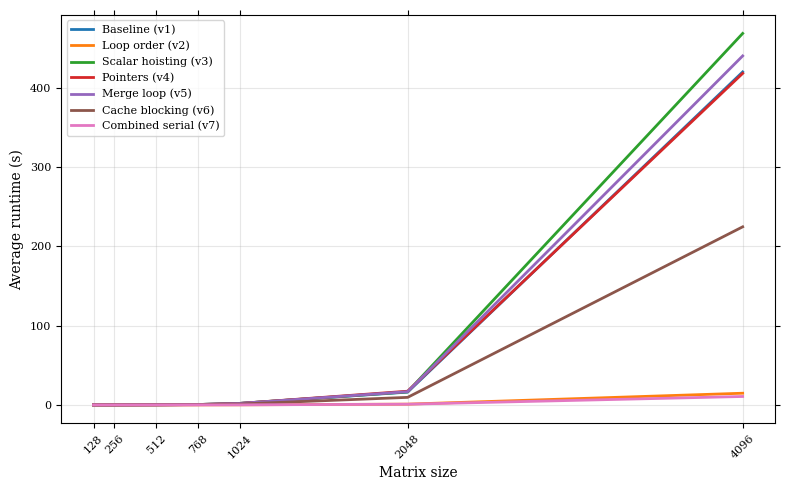

In [38]:
plot_matrix_size_curve(
    serial_data,
    title='Average Runtime vs Matrix Size (Serial Optimisations)',
    xtick_rotation=45,
)

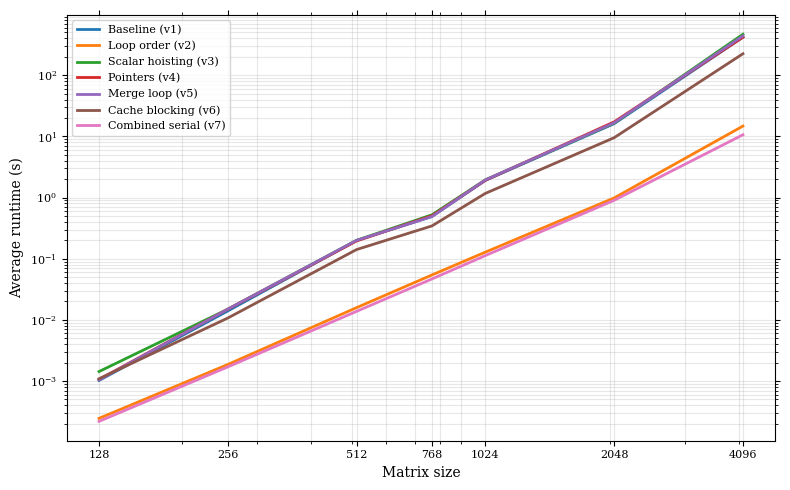

In [39]:
plot_matrix_size_curve(
    serial_data,
    title='Average Runtime vs Matrix Size (Serial Optimisations)',
    loglog=True,
    save_name='serial_optimisation_matrix_size',
)

In [40]:
comparison_table = build_comparison_table(serial_data)
print('Average Runtime (s) by Version:')
print(comparison_table.to_string())

Average Runtime (s) by Version:
             Baseline (v1)  Loop order (v2)  Scalar hoisting (v3)  Pointers (v4)  Merge loop (v5)  Cache blocking (v6)  Combined serial (v7)
matrix_size                                                                                                                                 
128               0.001023         0.000246              0.001430       0.001063         0.001044             0.001091              0.000219
256               0.014015         0.001867              0.014966       0.014928         0.014952             0.010730              0.001705
512               0.198937         0.015860              0.199950       0.195295         0.199658             0.141223              0.013789
768               0.490855         0.054250              0.522043       0.503444         0.488692             0.343763              0.046700
1024              1.909548         0.128166              1.950667       1.915562         1.942150             1.170255    

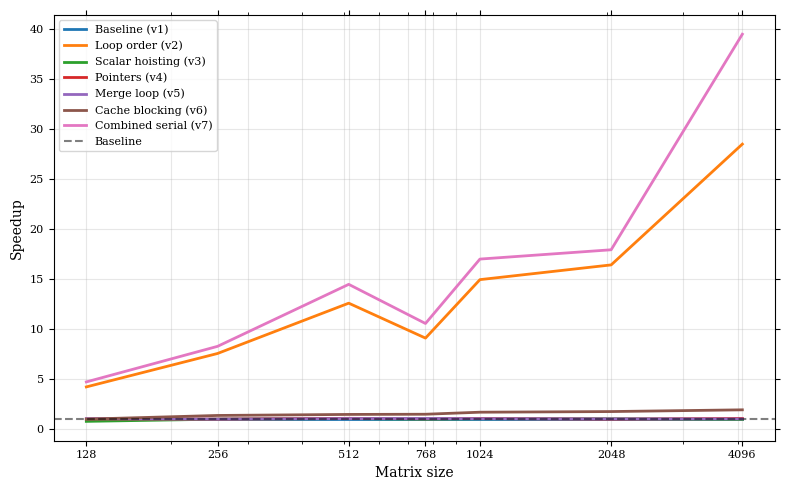

In [41]:
plot_speedup_vs_matrix(
    serial_data,
    serial_baseline,
    title='Speedup vs Matrix Size (Serial Optimisation)',
    save_name='serial_speedup_matrix_size',
)

In [42]:
serial_target_summary = performance_summary_at_size(
    serial_data, TARGET_SIZE, serial_baseline[TARGET_SIZE]
)

/var/folders/_k/xdz_dln924b3vlwpf4vz_hr80000gn/T/ipykernel_47326/1848539014.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/var/folders/_k/xdz_dln924b3vlwpf4vz_hr80000gn/T/ipykernel_47326/1848539014.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


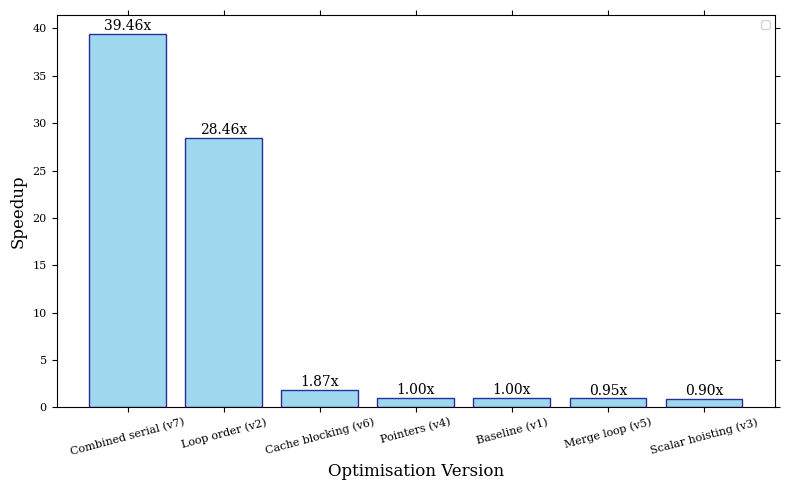

In [43]:
plt.figure(figsize=LATEX_FIGSIZE)
bars = plt.bar(
    serial_target_summary['Version'],
    serial_target_summary['Speedup (x)'],
    color='skyblue',
    edgecolor='navy',
    alpha=0.8,
)

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        yval + 0.05,
        f'{yval:.2f}x',
        ha='center',
        va='bottom',

    )
#plt.title(f'Speedup Comparison, Matrix Size: {TARGET_SIZE} (Serial Optimisation)', fontsize=12)
plt.ylabel('Speedup', fontsize=12)
plt.xlabel('Optimisation Version', fontsize=12)
plt.xticks(rotation=15)
plt.legend()
plt.tight_layout()
plt.legend()
plt.savefig(figure_path(f'speedup_at_{TARGET_SIZE}'), dpi=200)
plt.show()



OpenMP Optimisations

Performance Summary at Matrix Size 4096:
--------------------------------------------------
             Version  Avg Runtime (s)  Speedup (x)
Combined serial (v7)            10.63        39.46
     Loop order (v2)            14.74        28.46
 Cache blocking (v6)           224.45         1.87
       Pointers (v4)           417.81         1.00
       Baseline (v1)           419.63         1.00
     Merge loop (v5)           439.83         0.95
Scalar hoisting (v3)           468.15         0.90


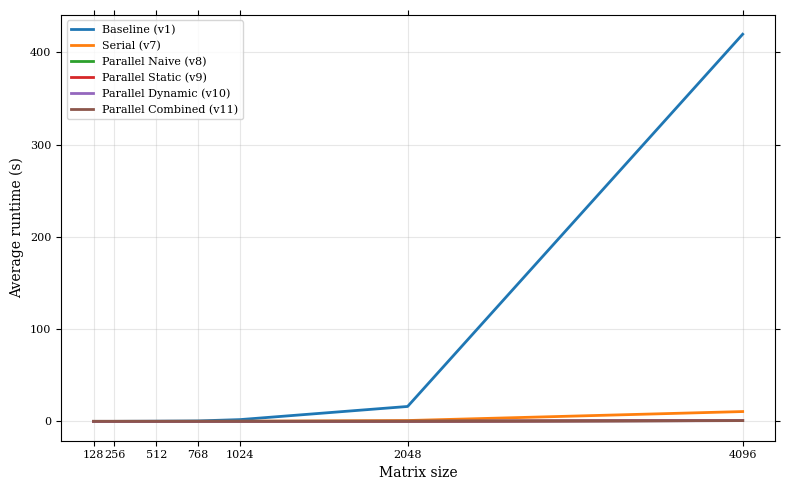

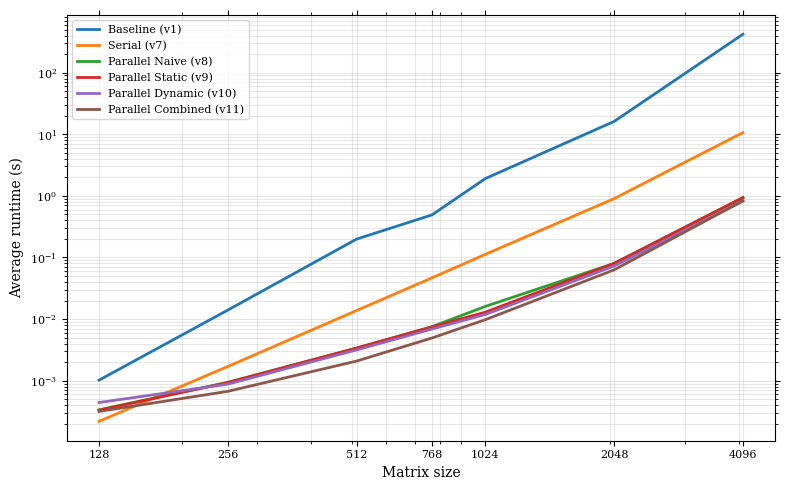

Performance Summary at Matrix Size 4096:
--------------------------------------------------
                Version  Avg Runtime (s)  Speedup (x)
 Parallel Dynamic (v10)             0.82       508.93
Parallel Combined (v11)             0.83       504.92
    Parallel Naive (v8)             0.93       448.96
   Parallel Static (v9)             0.94       447.65
            Serial (v7)            10.63        39.46
          Baseline (v1)           419.63         1.00


In [44]:
print(f'Performance Summary at Matrix Size {TARGET_SIZE}:')
print('-' * 50)
print(serial_target_summary.to_string(index=False))

plot_matrix_size_curve(
    parallel_matrix_data,
    title='Average Runtime vs Matrix Size (OpenMP Parallelisation)',
)

plot_matrix_size_curve(
    parallel_matrix_data,
    title='Average Runtime vs Matrix Size (OpenMP Parallelisation)',
    loglog=True,
    save_name='openmp_optimisation_matrix_size',
)

parallel_target_summary = performance_summary_at_size(
    parallel_matrix_data, TARGET_SIZE, parallel_baseline[TARGET_SIZE]
)
print(f'Performance Summary at Matrix Size {TARGET_SIZE}:')
print('-' * 50)
print(parallel_target_summary.to_string(index=False))

---

# Number of Threads Experiment

Matrix Size: 4096

Block Size: 64

Number of Threads: 1 to 70

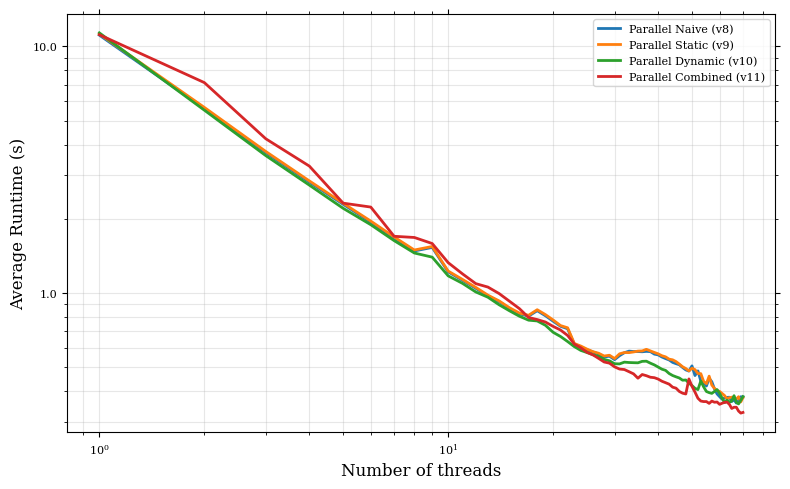

In [45]:
plt.figure(figsize=LATEX_FIGSIZE)
ax = plt.gca()
for entry in thread_data:
    df = entry['df']
    plt.loglog(
        df['num_threads'],
        df['average_time'],
        marker='',
        markersize=6,
        linewidth=2,
        label=entry['label'],
    )
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
#plt.title('Average Runtime vs Number of Threads (OpenMP Parallelisation)', fontsize=12)
plt.xlabel('Number of threads', fontsize=12)
plt.ylabel('Average Runtime (s)', fontsize=12)
plt.grid(True, which='both', ls='-', alpha=0.3)
plt.tight_layout()
plt.legend()
plt.savefig(figure_path('openmp_optimisation_number_threads'), dpi=200)
plt.show()

Speed Up $S_p$ measures how much faster the parallel program is compared to running on 1 thread:

$$S_p = \frac{T_1}{T_p}$$

$T_1$ - execution time with 1 thread
$T_p$ - execution time with p threads

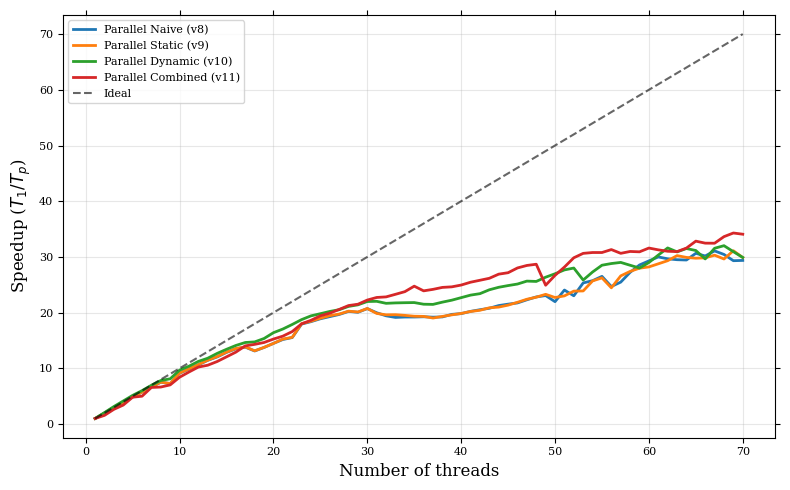

In [46]:
plt.figure(figsize=LATEX_FIGSIZE)
all_thread_counts = sorted({n for entry in thread_data for n in entry['df']['num_threads']})
for entry in thread_data:
    df = entry['df']
    plt.plot(
        df['num_threads'],
        df['speedup'],
        marker='',
        linewidth=2,
        label=entry['label'],
    )
plt.plot(all_thread_counts, all_thread_counts, 'k--', alpha=0.6, label='Ideal')
#plt.title('Speedup vs Number of Threads (OpenMP Parallelisation)', fontsize=12)
plt.xlabel('Number of threads', fontsize=12)
plt.ylabel('Speedup ($T_1 / T_p$)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.legend()
plt.savefig(figure_path('speedup_comparison'), dpi=200)
plt.show()

Efficiency $E_p$ measures the speed up normalised by the number of threads:
$$E_p = \frac{S_p}{p} = \frac{T_1}{p-T_p}$$

$E_p = 1$ - perfect scaling

$E_p < 1$ - some overhead

$E_p > 1$ - superlinear speedup

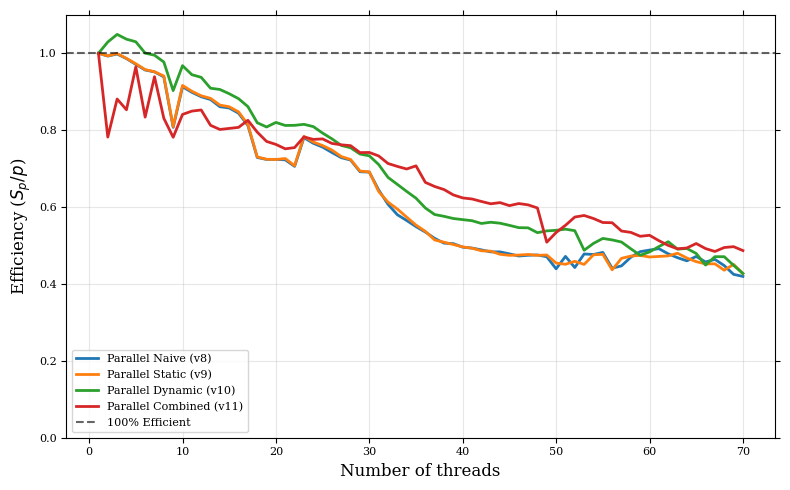

In [47]:
plt.figure(figsize=LATEX_FIGSIZE)
for entry in thread_data:
    df = entry['df']
    plt.plot(
        df['num_threads'],
        df['efficiency'],
        marker='',
        linewidth=2,
        label=entry['label'],
    )
plt.axhline(y=1.0, color='k', linestyle='--', alpha=0.6, label=f'100% Efficient')
#plt.title('Parallel Efficiency vs Number of Threads', fontsize=12)
plt.xlabel('Number of threads', fontsize=12)
plt.ylabel('Efficiency ($S_p / p$)', fontsize=12)
plt.ylim(0, 1.1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.legend()
plt.savefig(figure_path('parallel_efficiency_comparison'), dpi=200)
plt.show()

---

# Cache Blocking Experiment

Matrix Size: 1024

Number of Threads: 16

Block Sizes: 8, 16, 32, 64, 128, 256,512


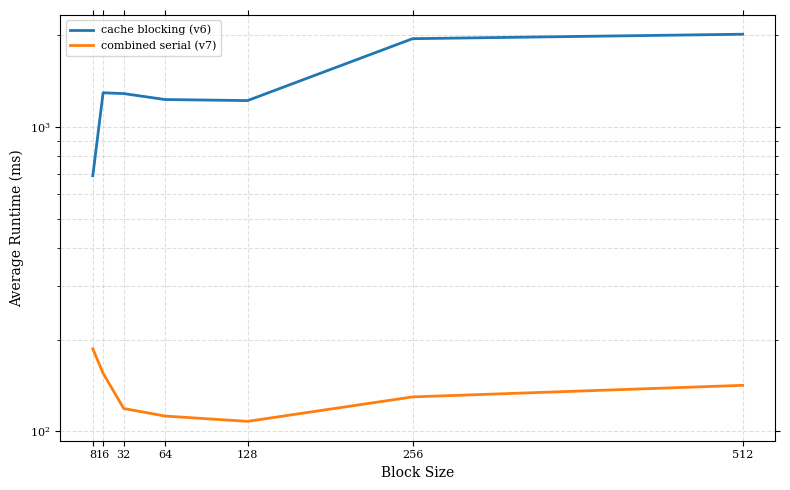

In [48]:
cache_block_path_v6 = CSV_PATH / 'v6_cache_blocking_block_size_runs.csv'
cache_block_df_v6 = pd.read_csv(cache_block_path_v6)
run_cols_v6 = run_columns(cache_block_df_v6)
cache_block_df_v6['avg_time'] = cache_block_df_v6[run_cols_v6].mean(axis=1)
block_avg_v6 = cache_block_df_v6.groupby('block_size', as_index=False)['avg_time'].mean()
block_avg_v6['avg_time_ms'] = block_avg_v6['avg_time'] * 1000

cache_block_path_v7 = CSV_PATH / 'v7_serial_block_size_runs.csv'
cache_block_df_v7 = pd.read_csv(cache_block_path_v7)
run_cols_v7 = run_columns(cache_block_df_v7)
cache_block_df_v7['avg_time'] = cache_block_df_v7[run_cols_v7].mean(axis=1)
block_avg_v7 = cache_block_df_v7.groupby('block_size', as_index=False)['avg_time'].mean()
block_avg_v7['avg_time_ms'] = block_avg_v7['avg_time'] * 1000

plt.figure(figsize=LATEX_FIGSIZE)
plt.plot(
    block_avg_v6['block_size'],
    block_avg_v6['avg_time_ms'],
    marker='',
    linestyle='-',
    linewidth=2,
    label='cache blocking (v6)',
)
plt.plot(
    block_avg_v7['block_size'],
    block_avg_v7['avg_time_ms'],
    marker='',
    linestyle='-',
    linewidth=2,
    label='combined serial (v7)',
)
all_block_sizes = sorted(set(block_avg_v6['block_size']).union(set(block_avg_v7['block_size'])))
plt.xticks(all_block_sizes, labels=[str(int(b)) for b in all_block_sizes], fontsize=8)
plt.xlabel('Block Size')
plt.ylabel('Average Runtime (ms)')
plt.yscale('log')
#plt.title('Average Runtime vs Block Size')
plt.grid(True, which='both', linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.savefig(figure_path('cache_blocking'), dpi=200)
plt.show()